In [1]:
# Imports standards
import pandas as pd
import numpy as np
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, recall_score, f1_score, 
    make_scorer, confusion_matrix, classification_report
)

# Modèles
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier

# Optimisation & Tracking
import optuna
from optuna.integration.mlflow import MLflowCallback
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

print("Imports reussis")
print(f"Versions:")
print(f"   - XGBoost:  {xgb.__version__}")
print(f"   - LightGBM: {lgb.__version__}")
print(f"   - Optuna:   {optuna.__version__}")
print(f"   - MLflow:   {mlflow.__version__}")

Imports reussis
Versions:
   - XGBoost:  3.2.0
   - LightGBM: 4.6.0
   - Optuna:   4.7.0
   - MLflow:   2.22.4


In [2]:
# Charger les features engineered
df = pd.read_parquet('../data/features_engineered.parquet')

# Séparer train et test
train = df[df['TARGET'].notna()].copy()
test = df[df['TARGET'].isna()].copy()

# Préparer pour l'entraînement
X_train = train.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y_train = train['TARGET']

# Pour les prédictions finales
X_test = test.drop(['TARGET', 'SK_ID_CURR'], axis=1)
test_ids = test['SK_ID_CURR']

print(f"Donnees chargees:")
print(f"   Train : {X_train.shape} ({len(y_train):,} echantillons)")
print(f"   Test  : {X_test.shape}")
print(f"\nDistribution des classes:")
print(f"   Classe 0: {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.1f}%)")
print(f"   Classe 1: {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.1f}%)")
print(f"   Ratio: 1:{(y_train == 0).sum() / (y_train == 1).sum():.1f}")

Donnees chargees:
   Train : (307507, 795) (307,507 echantillons)
   Test  : (48744, 795)

Distribution des classes:
   Classe 0: 282,682 (91.9%)
   Classe 1: 24,825 (8.1%)
   Ratio: 1:11.4


In [3]:
# Nettoyage des valeurs problématiques
print("Nettoyage des donnees...")

X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Donnees nettoyees: {X_train.shape}")

Nettoyage des donnees...
Donnees nettoyees: (307507, 795)


In [4]:
# Train/Val split pour le test rapide
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.2, 
    stratify=y_train, 
    random_state=42
)

print(f"Train subset: {X_tr.shape}")
print(f"Val subset:   {X_val.shape}")

Train subset: (246005, 795)
Val subset:   (61502, 795)


In [5]:
from pathlib import Path

tracking_uri = Path.cwd().parent / 'mlruns'
# Utiliser le chemin absolu au lieu de .as_uri() pour éviter les problèmes de format
mlflow.set_tracking_uri(str(tracking_uri.absolute()))

# Créer une NOUVELLE expérience pour Linux (évite les problèmes de chemins Windows)
EXPERIMENT_NAME = "Home Credit - Model Optimization - Linux"

try:
    mlflow.set_experiment(EXPERIMENT_NAME)
    print(f"✅ Expérience '{EXPERIMENT_NAME}' configurée")
except Exception as e:
    print(f"⚠️  Erreur lors de la configuration: {e}")
    # Créer avec un nom unique si problème
    EXPERIMENT_NAME = f"Home Credit - Optimization - {datetime.now().strftime('%Y%m%d_%H%M%S')}"

    mlflow.set_experiment(EXPERIMENT_NAME)
    print("\nMLflow configure avec succès!")

    print(f"✅ Nouvelle expérience créée: '{EXPERIMENT_NAME}'")    

    mlflow.end_run()

print(f"\nMLflow Tracking URI: {mlflow.get_tracking_uri()}")
if mlflow.active_run():
    print(f"Stockage: {tracking_uri.absolute()}")# Fermer toute run active

print(f"Experience: {EXPERIMENT_NAME}")

✅ Expérience 'Home Credit - Model Optimization - Linux' configurée

MLflow Tracking URI: /home/zmxw1768/Documents/oc_mlops/mlruns
Experience: Home Credit - Model Optimization - Linux


In [6]:
def business_cost_scorer(y_true, y_pred):
    """
    Coût métier : FN (faux négatif) coûte 10 fois plus cher que FP (faux positif)
    On retourne le négatif du coût pour maximiser (sklearn maximise les scores)
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = fp * 1 + fn * 10  # FN coûte 10x plus
    return -cost  # Négatif car on veut minimiser le coût

# Configuration de la validation croisée
N_SPLITS = 3
RANDOM_STATE = 42

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Définir les scorers
scoring = {
    'roc_auc': make_scorer(roc_auc_score, response_method='predict_proba'),
    'recall_minority': make_scorer(recall_score, pos_label=1, zero_division=0),
    'f1': make_scorer(f1_score, pos_label=1, zero_division=0),
    'business_cost': make_scorer(business_cost_scorer)
}

print(f"Metriques configurees:")
print(f"   - ROC-AUC")
print(f"   - Recall (classe minoritaire)")
print(f"   - F1-Score")
print(f"   - Cout metier (FN=10x FP)")

Metriques configurees:
   - ROC-AUC
   - Recall (classe minoritaire)
   - F1-Score
   - Cout metier (FN=10x FP)


In [7]:
# === DETECTION GPU/CPU AUTOMATIQUE ===
# Cette fonction detecte automatiquement la disponibilite du GPU
# Le code s'adaptera automatiquement selon le materiel disponible

def check_gpu_availability():
    """
    Detecte si un GPU est disponible pour XGBoost et LightGBM
    
    Returns:
        dict: Configuration GPU pour chaque framework
            - 'available': True si GPU detecte, False sinon
            - 'device': 'cuda'/'gpu' si disponible, 'cpu' sinon
    """
    gpu_config = {
        'xgboost': {'available': False, 'device': 'cpu'},
        'lightgbm': {'available': False, 'device': 'cpu'}
    }
    
    # Test XGBoost GPU
    print("Detection GPU pour XGBoost...")
    try:
        # Methode 1: Verifier via PyTorch si disponible
        import torch
        if torch.cuda.is_available():
            gpu_config['xgboost']['available'] = True
            gpu_config['xgboost']['device'] = 'cuda'
            gpu_name = torch.cuda.get_device_name(0)
            print(f"  -> GPU detecte: {gpu_name}")
    except ImportError:
        # Methode 2: Test direct avec XGBoost
        try:
            test_data = xgb.DMatrix(np.random.rand(10, 5), label=np.random.randint(0, 2, 10))
            xgb.train({'device': 'cuda', 'tree_method': 'hist'}, test_data, num_boost_round=1)
            gpu_config['xgboost']['available'] = True
            gpu_config['xgboost']['device'] = 'cuda'
            print("  -> GPU detecte")
        except Exception:
            print("  -> Pas de GPU, utilisation CPU")
    
    # Test LightGBM GPU
    print("\nDetection GPU pour LightGBM...")
    try:
        # LightGBM GPU necessite une compilation speciale
        test_data = lgb.Dataset(np.random.rand(10, 5), label=np.random.randint(0, 2, 10))
        lgb.train({'device': 'gpu', 'verbose': -1}, test_data, num_boost_round=1)
        gpu_config['lightgbm']['available'] = True
        gpu_config['lightgbm']['device'] = 'gpu'
        print("  -> GPU detecte")
    except Exception:
        print("  -> Pas de GPU, utilisation CPU")
    
    return gpu_config


# Executer la detection
print("="*80)
print("DETECTION DU MATERIEL DISPONIBLE")
print("="*80 + "\n")

GPU_CONFIG = check_gpu_availability()

print("\n" + "="*80)
print("CONFIGURATION FINALE:")
print("="*80)
print(f"XGBoost  : {GPU_CONFIG['xgboost']['device'].upper()}")
print(f"LightGBM : {GPU_CONFIG['lightgbm']['device'].upper()}")
print("="*80)

DETECTION DU MATERIEL DISPONIBLE

Detection GPU pour XGBoost...
  -> GPU detecte

Detection GPU pour LightGBM...
  -> Pas de GPU, utilisation CPU

CONFIGURATION FINALE:
XGBoost  : CUDA
LightGBM : CPU


In [8]:
def create_lightgbm_pipeline(params=None):
    """
    Pipeline LightGBM avec adaptation automatique GPU/CPU
    
    Args:
        params: Dictionnaire d'hyperparametres (optionnel)
        
    Returns:
        Pipeline sklearn avec scaler + LightGBM
    """
    # Parametres par defaut
    default_params = {
        'n_estimators': 100,
        'max_depth': -1,
        'learning_rate': 0.1,
        'num_leaves': 31,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_samples': 20,
        'reg_alpha': 0,
        'reg_lambda': 0,
        'random_state': RANDOM_STATE,
        'verbose': -1
    }
    
    # === ADAPTATION GPU/CPU AUTOMATIQUE ===
    if GPU_CONFIG['lightgbm']['available']:
        # Configuration GPU
        default_params['device'] = 'gpu'
        default_params['gpu_use_dp'] = False  # Single precision = plus rapide
        default_params['max_bin'] = 255  # Optimal pour GPU LightGBM
        # PAS de n_jobs avec GPU (conflit)
    else:
        # Configuration CPU
        default_params['device'] = 'cpu'
        default_params['n_jobs'] = -1  # Multiprocessing CPU
    
    # Merge avec parametres personnalises
    if params:
        # Si params force le device, adapter les parametres associes
        if 'device' in params:
            if params['device'] == 'gpu':
                params['gpu_use_dp'] = params.get('gpu_use_dp', False)
                params['max_bin'] = params.get('max_bin', 255)
                params.pop('n_jobs', None)  # Retirer n_jobs si present
            elif params['device'] == 'cpu':
                params.pop('gpu_use_dp', None)
                if 'n_jobs' not in params:
                    params['n_jobs'] = -1
        
        default_params.update(params)
    
    # Gestion du desequilibre des classes
    default_params['is_unbalance'] = True
    
    # Creation du pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', lgb.LGBMClassifier(**default_params))
    ])
    
    return pipeline

print("Pipeline LightGBM cree")
print(f"  Mode: {GPU_CONFIG['lightgbm']['device'].upper()}")

Pipeline LightGBM cree
  Mode: CPU


## 🚀 Lancement des Optimisations

**⚠️ IMPORTANT:** Ajustez `n_trials` selon vos ressources :
- **Rapide** : 20-30 trials (~5-10 min par modèle)
- **Normal** : 50-100 trials (~15-30 min par modèle)
- **Complet** : 100-200 trials (~30-60 min par modèle)

Vous pouvez aussi utiliser `timeout` (en secondes) pour limiter le temps.

In [9]:
# Configuration d'optimisation
N_TRIALS = 30  # Ajustez selon votre temps disponible
OPTIMIZATION_METRIC = 'roc_auc'  # ou 'f1', 'recall_minority', 'business_cost'

# Stocker les résultats
optimization_results = {}

print(f"Configuration:")
print(f"   Trials par modele: {N_TRIALS}")
print(f"   Metrique: {OPTIMIZATION_METRIC}")
print(f"   Temps estime: {N_TRIALS * 3 // 60}-{N_TRIALS * 5 // 60} min par modele")

Configuration:
   Trials par modele: 30
   Metrique: roc_auc
   Temps estime: 1-2 min par modele


### Lancer l'optimisation avec undersampling

In [10]:
def optimize_model_undersampled(model_type, X_resampled, y_resampled, X_holdout=None, y_holdout=None, n_trials=50, metric='roc_auc', timeout=None):
    """
    Optimise un modele avec Optuna sur donnees sous-echantillonnees
    
    Args:
        model_type: 'xgboost', 'lightgbm' or 'mlp'
        X_resampled: Features sous-echantillonnees
        y_resampled: Target sous-echantillonnes
        X_holdout: Features du holdout set (optionnel)
        y_holdout: Target du holdout set (optionnel)
        n_trials: Nombre de trials Optuna
        metric: Metrique a optimiser
        timeout: Timeout en secondes (optionnel)
    
    Returns:
        best_params: Meilleurs hyperparametres
        best_value: Meilleure valeur de la metrique
        study: Objet Study Optuna
    """
    
    print(f"\n{'='*80}")
    print(f"OPTIMISATION UNDERSAMPLED: {model_type.upper()}")
    print(f"{'='*80}")
    print(f"Metrique: {metric}")
    print(f"Trials: {n_trials}")
    print(f"CV: {N_SPLITS} folds")
    print(f"Dataset: {len(X_resampled):,} echantillons (apres undersampling)")
    if X_holdout is not None:
        print(f"Holdout: {len(X_holdout):,} echantillons (evaluation finale)")
    
    # Creer une etude Optuna
    study_name = f"{model_type}_undersampled_{metric}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    
    direction = 'maximize'
    
    study = optuna.create_study(
        study_name=study_name,
        direction=direction,
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    
    # Callback MLflow
    try:
        current_experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
        experiment_id = current_experiment.experiment_id
    except:
        # Si l'expérience n'existe pas, la créer
        experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
    
    mlflow_callback = MLflowCallback(
        tracking_uri=mlflow.get_tracking_uri(),
        metric_name=metric,
        create_experiment=False,
        mlflow_kwargs={
            "experiment_id": experiment_id,
            "nested": True
        }
    )
    
    # Lancer l'optimisation
    with mlflow.start_run(run_name=f"{model_type.upper()} - Undersampled - Optuna {n_trials} trials"):
        
        mlflow.set_tags({
            "author": "Data Science Team",
            "project": "Home Credit Default Risk",
            "phase": "optimization",
            "model_type": model_type,
            "optimizer": "optuna",
            "framework": model_type if model_type != 'mlp' else 'sklearn',
            "environment": "development",
            "sampling_strategy": "undersampling",
            "sampling_ratio": f"1:{1/sampling_strategy:.0f}"
        })
        
        mlflow.set_tag("mlflow.note.content", f"""
OPTIMISATION AVEC UNDERSAMPLING - {model_type.upper()}

Configuration:
- Optimiseur: Optuna (TPE Sampler)
- Nombre de trials: {n_trials}
- Metrique objectif: {metric}
- Validation: StratifiedKFold ({N_SPLITS} folds)
- Echantillons: {len(X_resampled):,} (apres undersampling)
- Sampling ratio: 1:{1/sampling_strategy:.0f}
- Holdout: {'Oui' if X_holdout is not None else 'Non'}

Strategie:
- RandomUnderSampler de la classe majoritaire
- Objectif: ameliorer la detection des defauts (recall)

Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}
        """)
        
        # Logger les parametres
        mlflow.log_param("model_type", model_type)
        mlflow.log_param("n_trials", n_trials)
        mlflow.log_param("metric", metric)
        mlflow.log_param("cv_folds", N_SPLITS)
        mlflow.log_param("n_samples_original", len(X_train))
        mlflow.log_param("n_samples_resampled", len(X_resampled))
        mlflow.log_param("sampling_strategy", "undersampling")
        mlflow.log_param("sampling_ratio", f"1:{1/sampling_strategy:.0f}")
        mlflow.log_param("n_features", X_resampled.shape[1])
        if X_holdout is not None:
            mlflow.log_param("n_samples_holdout", len(X_holdout))
        
        # Fonction objectif adaptee
        def objective_undersampled(trial):
            if model_type == 'lightgbm':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
                    'max_depth': trial.suggest_int('max_depth', 3, 15),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                    'num_leaves': trial.suggest_int('num_leaves', 20, 150),
                    'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                    'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
                    'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
                    'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
                }
                
                # Configuration GPU/CPU
                if GPU_CONFIG['lightgbm']['available']:
                    params['device'] = 'gpu'
                    params['gpu_use_dp'] = False
                    params['max_bin'] = 255
                else:
                    params['device'] = 'cpu'
                    params['n_jobs'] = -1
                
                # PAS de is_unbalance car donnees deja equilibrees
                params['random_state'] = RANDOM_STATE
                params['verbose'] = -1
                
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('classifier', lgb.LGBMClassifier(**params))
                ])
            else:
                raise ValueError(f"Seul LightGBM est supporte pour l'instant")
            
            try:
                cv_results = cross_validate(
                    pipeline, 
                    X_resampled, 
                    y_resampled, 
                    cv=skf, 
                    scoring=scoring,
                    n_jobs=1,
                    return_train_score=False,
                    error_score='raise'
                )
                
                mean_score = np.mean(cv_results[f'test_{metric}'])
                return mean_score
                
            except Exception as e:
                print(f"Erreur dans le trial: {e}")
                return -np.inf if metric == 'business_cost' else 0.0
        
        # Optimiser
        study.optimize(
            objective_undersampled,
            n_trials=n_trials,
            timeout=timeout,
            callbacks=[mlflow_callback],
            show_progress_bar=True
        )
        
        # Resultats
        best_params = study.best_params
        best_value = study.best_value
        
        print(f"\n{'='*80}")
        print(f"OPTIMISATION TERMINEE")
        print(f"{'='*80}")
        print(f"Meilleur {metric}: {best_value:.4f}")
        print(f"\nMeilleurs hyperparametres:")
        for param, value in best_params.items():
            print(f"   {param:25s}: {value}")
        
        # Logger les meilleurs resultats
        mlflow.log_metric(f"best_{metric}", best_value)
        for param, value in best_params.items():
            mlflow.log_param(f"best_{param}", value)
        
        # Entrainer le modele final
        print(f"\nEntrainement du modele final...")
        
        if model_type == 'lightgbm':
            final_params = best_params.copy()
            if GPU_CONFIG['lightgbm']['available']:
                final_params['device'] = 'gpu'
                final_params['gpu_use_dp'] = False
                final_params['max_bin'] = 255
            else:
                final_params['device'] = 'cpu'
                final_params['n_jobs'] = -1
            
            final_params['random_state'] = RANDOM_STATE
            final_params['verbose'] = -1
            
            best_pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('classifier', lgb.LGBMClassifier(**final_params))
            ])
        
        # Validation croisee finale
        final_cv = cross_validate(
            best_pipeline,
            X_resampled,
            y_resampled,
            cv=skf,
            scoring=scoring,
            n_jobs=1,
            return_train_score=False
        )
        
        # Logger toutes les metriques finales
        print(f"\n{'='*80}")
        print(f"RESULTATS VALIDATION CROISEE (sur donnees undersampled)")
        print(f"{'='*80}")
        for metric_name in scoring.keys():
            scores = final_cv[f'test_{metric_name}']
            mean_val = np.mean(scores)
            std_val = np.std(scores)
            
            mlflow.log_metric(f"{metric_name}_mean", mean_val)
            mlflow.log_metric(f"{metric_name}_std", std_val)
            
            print(f"   {metric_name:20s}: {mean_val:.4f} (±{std_val:.4f})")
        
        # Entrainer sur toutes les donnees resamplees
        best_pipeline.fit(X_resampled, y_resampled)
        
        # === EVALUATION SUR LE HOLDOUT SET ===
        if X_holdout is not None and y_holdout is not None:
            print(f"\n{'='*80}")
            print(f"EVALUATION SUR HOLDOUT SET (10% jamais vu)")
            print(f"{'='*80}")
            print(f"   Echantillons: {len(X_holdout):,}")
            print(f"   Distribution: Classe 0: {(y_holdout == 0).mean()*100:.1f}% | Classe 1: {(y_holdout == 1).mean()*100:.1f}%")
            print()
            
            y_pred_proba_holdout = best_pipeline.predict_proba(X_holdout)[:, 1]
            y_pred_holdout = best_pipeline.predict(X_holdout)
            
            auc_holdout = roc_auc_score(y_holdout, y_pred_proba_holdout)
            recall_holdout = recall_score(y_holdout, y_pred_holdout)
            f1_holdout = f1_score(y_holdout, y_pred_holdout)
            
            # Calcul du cout metier sur holdout
            tn, fp, fn, tp = confusion_matrix(y_holdout, y_pred_holdout).ravel()
            business_cost_holdout = fp * 1 + fn * 10
            
            print(f"   ROC-AUC      : {auc_holdout:.4f}")
            print(f"   Recall       : {recall_holdout:.4f}")
            print(f"   F1-Score     : {f1_holdout:.4f}")
            print(f"   Business Cost: {business_cost_holdout:,.0f}")
            print(f"\n   Matrice de confusion:")
            print(f"      TN: {tn:,} | FP: {fp:,}")
            print(f"      FN: {fn:,} | TP: {tp:,}")
            
            mlflow.log_metric("holdout_roc_auc", auc_holdout)
            mlflow.log_metric("holdout_recall", recall_holdout)
            mlflow.log_metric("holdout_f1", f1_holdout)
            mlflow.log_metric("holdout_business_cost", business_cost_holdout)
            mlflow.log_metric("holdout_tp", int(tp))
            mlflow.log_metric("holdout_tn", int(tn))
            mlflow.log_metric("holdout_fp", int(fp))
            mlflow.log_metric("holdout_fn", int(fn))
        
        # Sauvegarder le modele
        mlflow.sklearn.log_model(
            best_pipeline,
            "model",
            signature=mlflow.models.signature.infer_signature(X_resampled, y_pred_proba_holdout if X_holdout is not None else best_pipeline.predict_proba(X_resampled)[:, 1]),
            input_example=X_resampled[:1]

        )
        print("Fonction optimize_model_undersampled() definie")

        

        print(f"\nModele sauvegarde dans MLflow")    
        return best_params, best_value, study
    

In [11]:
from imblearn.under_sampling import RandomUnderSampler

# === ETAPE 1: SEPARER 10% DU DATASET POUR HOLDOUT ===
# Ce holdout ne sera jamais touché pendant l'optimisation
print("="*80)
print("SEPARATION HOLDOUT SET (10% du dataset)")
print("="*80)

X_train_work, X_holdout, y_train_work, y_holdout = train_test_split(
    X_train, 
    y_train,
    test_size=0.1,  # 10% pour holdout
    stratify=y_train,  # Stratifié pour garder la distribution
    random_state=RANDOM_STATE
)

print(f"\nDataset de travail (90%):")
print(f"   Classe 0: {(y_train_work == 0).sum():,} ({(y_train_work == 0).mean()*100:.1f}%)")
print(f"   Classe 1: {(y_train_work == 1).sum():,} ({(y_train_work == 1).mean()*100:.1f}%)")
print(f"   Total: {len(y_train_work):,} echantillons")

print(f"\nHoldout set (10% - NON TOUCHE):")
print(f"   Classe 0: {(y_holdout == 0).sum():,} ({(y_holdout == 0).mean()*100:.1f}%)")
print(f"   Classe 1: {(y_holdout == 1).sum():,} ({(y_holdout == 1).mean()*100:.1f}%)")
print(f"   Total: {len(y_holdout):,} echantillons")

# === ETAPE 2: UNDERSAMPLING SUR LES 90% RESTANTS ===
print(f"\n{'='*80}")
print("UNDERSAMPLING DU DATASET DE TRAVAIL")
print("="*80)

# Configuration de l'undersampling
# Ratio 1:1 (equilibrage parfait)
sampling_strategy = 1  # 0.5 = 1:2, 1.0 = 1:1

rus = RandomUnderSampler(
    sampling_strategy=sampling_strategy,
    random_state=RANDOM_STATE
)

# Appliquer l'undersampling sur le dataset de travail uniquement
X_train_resampled, y_train_resampled = rus.fit_resample(X_train_work, y_train_work)

print(f"\nDataset de travail AVANT undersampling:")
print(f"   Classe 0: {(y_train_work == 0).sum():,} ({(y_train_work == 0).mean()*100:.1f}%)")
print(f"   Classe 1: {(y_train_work == 1).sum():,} ({(y_train_work == 1).mean()*100:.1f}%)")
print(f"   Total: {len(y_train_work):,} echantillons")

print(f"\nDataset de travail APRES undersampling (ratio 1:{1/sampling_strategy:.0f}):")
print(f"   Classe 0: {(y_train_resampled == 0).sum():,} ({(y_train_resampled == 0).mean()*100:.1f}%)")
print(f"   Classe 1: {(y_train_resampled == 1).sum():,} ({(y_train_resampled == 1).mean()*100:.1f}%)")
print(f"   Total: {len(y_train_resampled):,} echantillons")
print(f"   Reduction: {(1 - len(y_train_resampled)/len(y_train_work))*100:.1f}%")

print(f"\n{'='*80}")
print("RECAPITULATIF")
print("="*80)
print(f"Dataset original        : {len(y_train):,} echantillons")
print(f"Dataset de travail (90%): {len(y_train_work):,} echantillons")
print(f"Apres undersampling     : {len(y_train_resampled):,} echantillons")
print(f"Holdout reserve (10%)   : {len(y_holdout):,} echantillons")
print("="*80)

SEPARATION HOLDOUT SET (10% du dataset)

Dataset de travail (90%):
   Classe 0: 254,414 (91.9%)
   Classe 1: 22,342 (8.1%)
   Total: 276,756 echantillons

Holdout set (10% - NON TOUCHE):
   Classe 0: 28,268 (91.9%)
   Classe 1: 2,483 (8.1%)
   Total: 30,751 echantillons

UNDERSAMPLING DU DATASET DE TRAVAIL

Dataset de travail AVANT undersampling:
   Classe 0: 254,414 (91.9%)
   Classe 1: 22,342 (8.1%)
   Total: 276,756 echantillons

Dataset de travail APRES undersampling (ratio 1:1):
   Classe 0: 22,342 (50.0%)
   Classe 1: 22,342 (50.0%)
   Total: 44,684 echantillons
   Reduction: 83.9%

RECAPITULATIF
Dataset original        : 307,507 echantillons
Dataset de travail (90%): 276,756 echantillons
Apres undersampling     : 44,684 echantillons
Holdout reserve (10%)   : 30,751 echantillons


In [12]:
# Optimiser LightGBM avec undersampling
lgb_under_params, lgb_under_score, lgb_under_study = optimize_model_undersampled(
    model_type='lightgbm',
    X_resampled=X_train_resampled,
    y_resampled=y_train_resampled,
    X_holdout=X_holdout,  # Passer le holdout set pour evaluation finale
    y_holdout=y_holdout,
    n_trials=20, # Ajustez selon votre temps disponible
    metric=OPTIMIZATION_METRIC
)

# Stocker les resultats
optimization_results['lightgbm_undersampled'] = {
    'params': lgb_under_params,
    'score': lgb_under_score,
    'study': lgb_under_study
}

[I 2026-02-25 08:57:06,928] A new study created in memory with name: lightgbm_undersampled_roc_auc_20260225_085706



OPTIMISATION UNDERSAMPLED: LIGHTGBM
Metrique: roc_auc
Trials: 20
CV: 3 folds
Dataset: 44,684 echantillons (apres undersampling)
Holdout: 30,751 echantillons (evaluation finale)


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-02-25 08:58:34,065] Trial 0 finished with value: 0.7720415001252389 and parameters: {'n_estimators': 150, 'max_depth': 15, 'learning_rate': 0.1205712628744377, 'num_leaves': 98, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'min_child_samples': 7, 'reg_alpha': 8.661761457749352, 'reg_lambda': 6.011150117432088}. Best is trial 0 with value: 0.7720415001252389.
[I 2026-02-25 08:58:56,810] Trial 1 finished with value: 0.7750657884878224 and parameters: {'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'num_leaves': 129, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'min_child_samples': 13, 'reg_alpha': 3.0424224295953772, 'reg_lambda': 5.247564316322379}. Best is trial 1 with value: 0.7750657884878224.
[I 2026-02-25 08:59:33,090] Trial 2 finished with value: 0.7756200177221073 and parameters: {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.08012737503998542, 'num_leaves': 38, 'subsample': 0.7168

2026/02/25 09:26:13 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
2026/02/25 09:26:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/02/25 09:26:17 WARNING mlflow.models.model: Failed to validate serving input example {
  "dataframe_split": {
    "columns": [
      "CODE_GENDER",
      "FLAG_OWN_CAR",
      "FLAG_OWN_REALTY",
      "CNT_CHILDREN",
      "AMT_INCOME_TOTAL",
      "AMT_CREDIT",
      "AMT_ANNUITY",
      "AMT_GOODS_PRICE",
      "REGION_POPULATION_RELATIVE",
      "DAYS_BIRTH",
      "DAYS_EMPLOYED",
      "DAYS_REGISTRATION",
      "DAYS_ID_PUBLISH",
      "OWN_CAR_AGE",
      "FLAG_MOBIL",
      "FLAG_EMP_PHONE",
      "FLAG_WORK_PHONE",
     

Fonction optimize_model_undersampled() definie

Modele sauvegarde dans MLflow


## 🔍 Analyse des Features Importantes et Réduction de Dimensionnalité

Dans cette section, nous allons :
1. **Extraire les features les plus importantes** via SHAP values
2. **Réentraîner le modèle** avec seulement les top N features
3. **Comparer les performances** (modèle complet vs modèle réduit)

**Objectif** : Simplifier le modèle sans sacrifier les performances

In [13]:
# === CONFIGURATION ===
# Nombre de features à conserver (modifiable)
TOP_N_FEATURES = 20

print(f"Configuration:")
print(f"   Nombre de features à conserver: {TOP_N_FEATURES}")
print(f"   Nombre total de features: {X_train_resampled.shape[1]}")

Configuration:
   Nombre de features à conserver: 20
   Nombre total de features: 795


In [14]:
import shap
import matplotlib.pyplot as plt

print("="*80)
print("EXTRACTION DES FEATURE IMPORTANCES AVEC SHAP")
print("="*80)

# Récupérer le meilleur modèle depuis le pipeline
best_lgb_model = None

# Recherche du meilleur modèle dans les résultats d'optimisation
if 'lightgbm_undersampled' in optimization_results:
    # Recréer le pipeline avec les meilleurs paramètres
    best_params_lgb = optimization_results['lightgbm_undersampled']['params']
    
    # Configuration GPU/CPU
    if GPU_CONFIG['lightgbm']['available']:
        best_params_lgb['device'] = 'gpu'
        best_params_lgb['gpu_use_dp'] = False
        best_params_lgb['max_bin'] = 255
    else:
        best_params_lgb['device'] = 'cpu'
        best_params_lgb['n_jobs'] = -1
    
    best_params_lgb['random_state'] = RANDOM_STATE
    best_params_lgb['verbose'] = -1
    
    # Créer et entraîner le pipeline
    best_pipeline_lgb = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', lgb.LGBMClassifier(**best_params_lgb))
    ])
    
    # Entraîner sur les données undersampled
    best_pipeline_lgb.fit(X_train_resampled, y_train_resampled)
    
    # Extraire le modèle LightGBM
    best_lgb_model = best_pipeline_lgb.named_steps['classifier']
    
    print(f"\nModèle LightGBM entraîné avec {X_train_resampled.shape[1]} features")
else:
    print("ERREUR: Aucun résultat d'optimisation trouvé!")
    raise ValueError("Exécutez d'abord la cellule d'optimisation")

# === CALCUL DES SHAP VALUES ===
print(f"\n{'='*80}")
print("CALCUL DES SHAP VALUES")
print("="*80)

# Créer l'explainer SHAP pour LightGBM
# On utilise un échantillon pour accélérer le calcul
sample_size = min(1000, len(X_train_resampled))
X_sample = X_train_resampled.sample(n=sample_size, random_state=RANDOM_STATE)

# Scaler l'échantillon
X_sample_scaled = best_pipeline_lgb.named_steps['scaler'].transform(X_sample)

print(f"Calcul des SHAP values sur {sample_size} échantillons...")
explainer = shap.TreeExplainer(best_lgb_model)
shap_values = explainer.shap_values(X_sample_scaled)

# Pour un classifieur binaire, shap_values peut être une liste [class_0, class_1]
# On prend les valeurs pour la classe positive (classe 1)
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# Calculer l'importance moyenne absolue pour chaque feature
feature_importance = np.abs(shap_values_class1).mean(axis=0)

# Créer un DataFrame avec les importances
feature_names = X_train_resampled.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(f"\nTop {TOP_N_FEATURES} features les plus importantes:")
print("="*80)
for idx, row in importance_df.head(TOP_N_FEATURES).iterrows():
    print(f"   {row['feature']:50s}: {row['importance']:.6f}")

# Sélectionner les top N features
top_features = importance_df.head(TOP_N_FEATURES)['feature'].tolist()

print(f"\n{'='*80}")
print(f"FEATURES SELECTIONNEES: {len(top_features)}")
print("="*80)

EXTRACTION DES FEATURE IMPORTANCES AVEC SHAP

Modèle LightGBM entraîné avec 795 features

CALCUL DES SHAP VALUES
Calcul des SHAP values sur 1000 échantillons...

Top 20 features les plus importantes:
   EXT_SOURCE_2                                      : 0.345005
   EXT_SOURCE_3                                      : 0.329559
   EXT_SOURCE_1                                      : 0.128657
   CODE_GENDER                                       : 0.115475
   AMT_ANNUITY                                       : 0.096014
   PAYMENT_RATE                                      : 0.094708
   DAYS_BIRTH                                        : 0.092327
   APPROVED_CNT_PAYMENT_MEAN                         : 0.091998
   AMT_GOODS_PRICE                                   : 0.091421
   INSTAL_DPD_MEAN                                   : 0.084605
   NAME_FAMILY_STATUS_Married                        : 0.062387
   PREV_CNT_PAYMENT_MEAN                             : 0.053157
   BURO_AMT_CREDIT_SUM_DEBT_MEAN

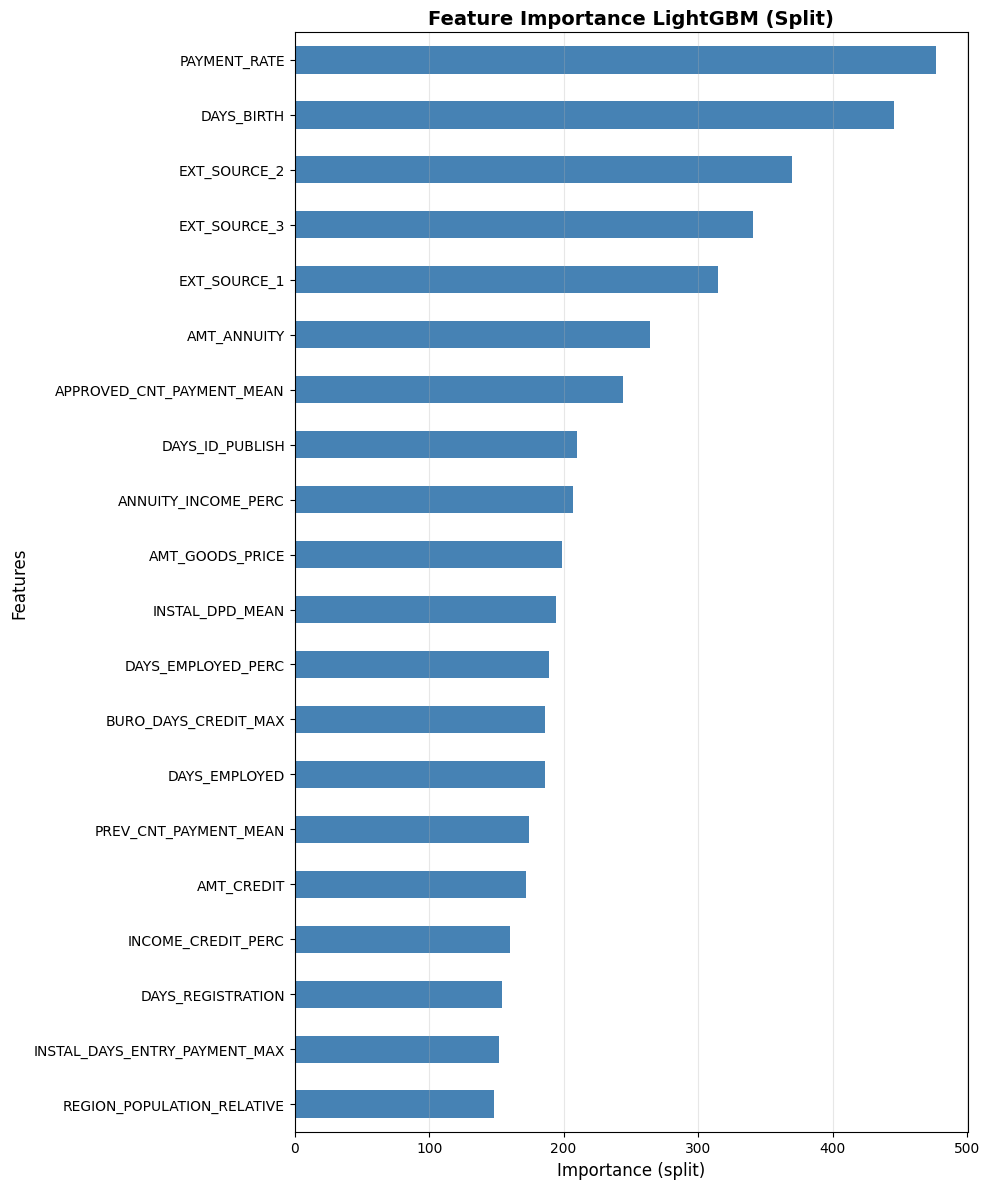

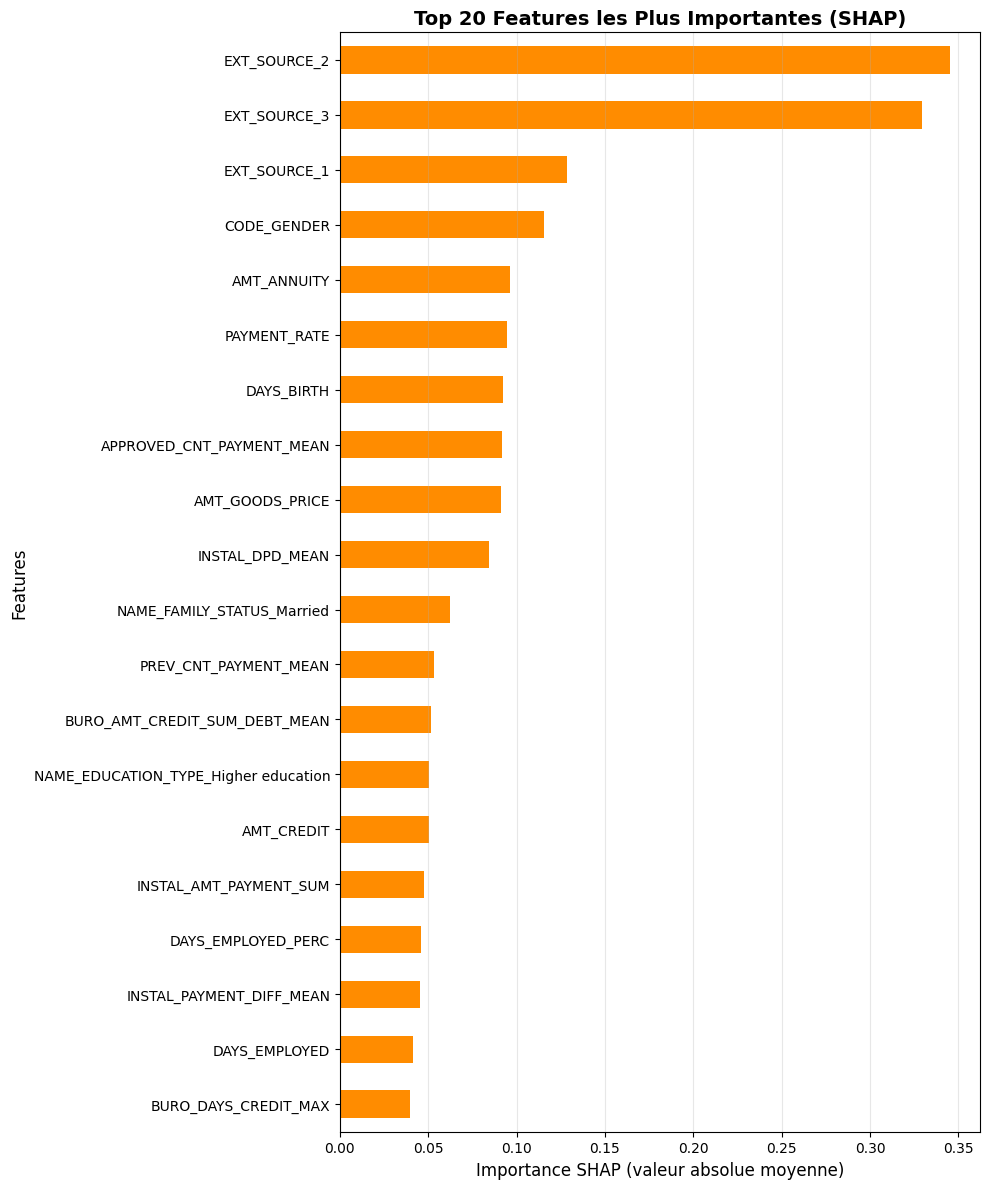


BEESWARM PLOT (SHAP)


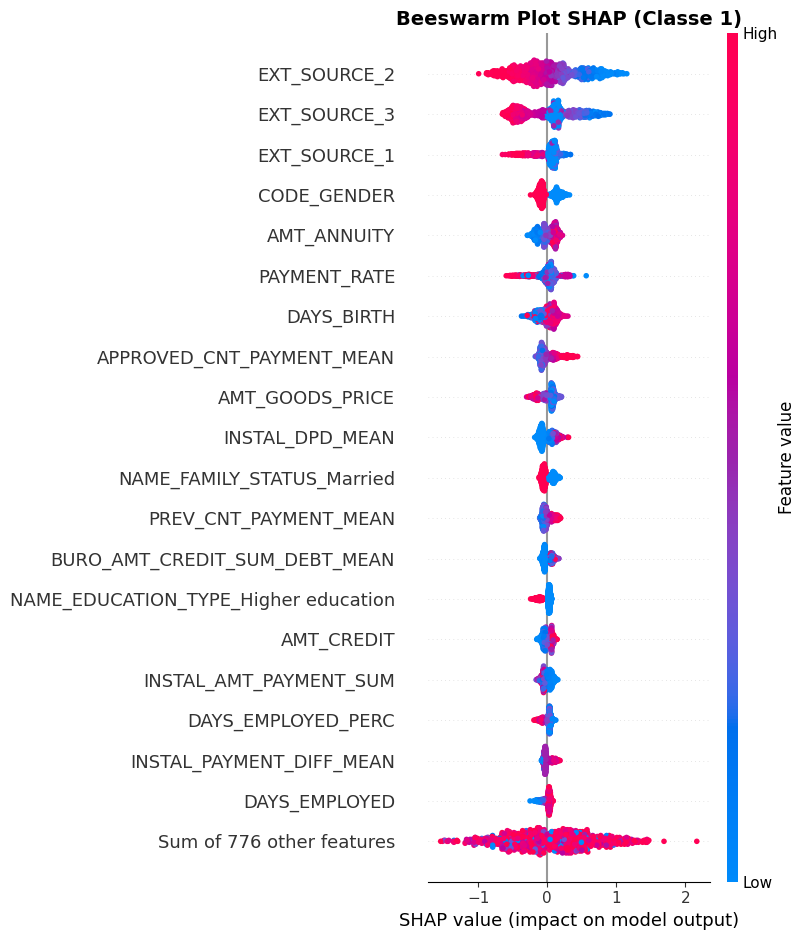


WATERFALL PLOT - Exemple de prédiction CLASSE 0
Échantillon index: 0 — Prédiction: Classe 0


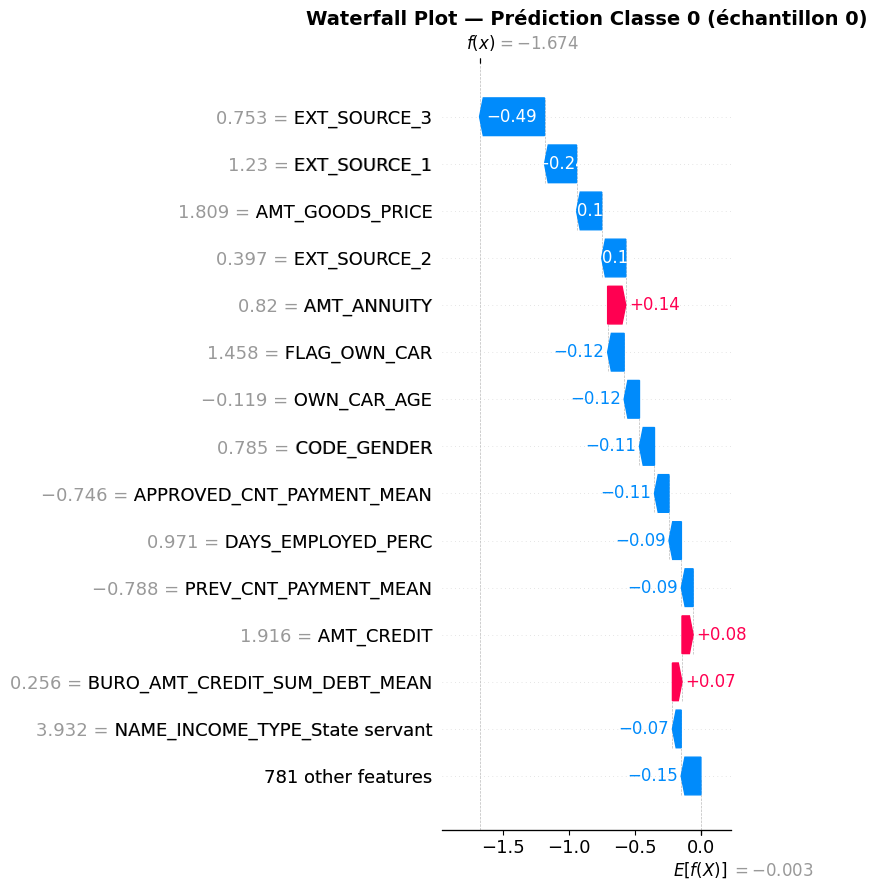


WATERFALL PLOT - Exemple de prédiction CLASSE 1
Échantillon index: 1 — Prédiction: Classe 1


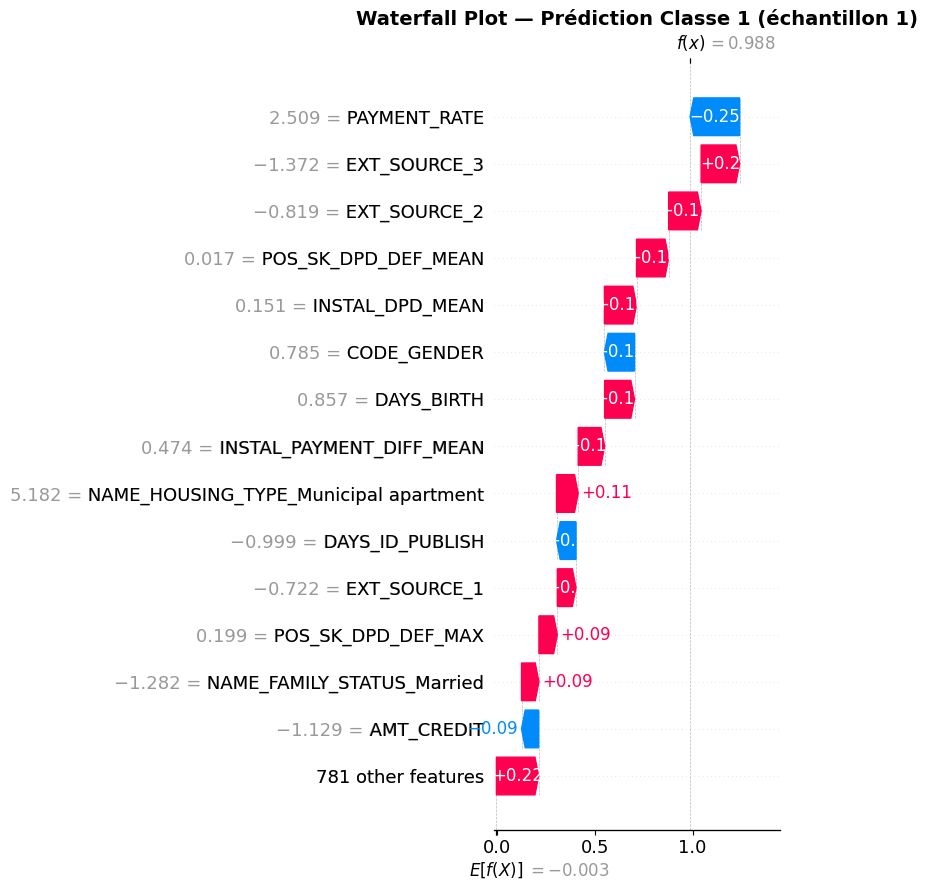


VISUALISATIONS TERMINÉES


In [17]:
# === VISUALISATION DES FEATURE IMPORTANCES ===

# --- 1. Feature Importance native LightGBM (avec vrais noms de features) ---
fig, ax = plt.subplots(figsize=(10, 12))

# Récupérer les importances et associer les vrais noms
lgb_importances = best_lgb_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': lgb_importances
}).sort_values('importance', ascending=True).tail(min(TOP_N_FEATURES, 40))

feat_imp_df.plot(kind='barh', x='feature', y='importance', ax=ax, color='steelblue', legend=False)
ax.set_title('Feature Importance LightGBM (Split)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance (split)', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 2. Feature Importance SHAP (valeur absolue moyenne) ---
fig, ax = plt.subplots(figsize=(10, 12))

top_n_viz = min(TOP_N_FEATURES, 40)
importance_df.head(top_n_viz).sort_values('importance').plot(
    kind='barh',
    x='feature',
    y='importance',
    ax=ax,
    color='darkorange',
    legend=False
)

ax.set_xlabel('Importance SHAP (valeur absolue moyenne)', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title(f'Top {top_n_viz} Features les Plus Importantes (SHAP)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# --- 3. Beeswarm SHAP ---
print(f"\n{'='*80}")
print("BEESWARM PLOT (SHAP)")
print("="*80)

# Créer un objet Explanation pour les plots SHAP modernes
explanation = shap.Explanation(
    values=shap_values_class1,
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    data=X_sample_scaled,
    feature_names=list(feature_names)
)

fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.beeswarm(explanation, max_display=min(TOP_N_FEATURES, 20), show=False)
plt.title('Beeswarm Plot SHAP (Classe 1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 4. Waterfall Plot - Prédiction classe 0 ---
print(f"\n{'='*80}")
print("WATERFALL PLOT - Exemple de prédiction CLASSE 0")
print("="*80)

# Trouver un échantillon prédit comme classe 0
y_pred_sample = best_lgb_model.predict(X_sample_scaled)
idx_class0 = np.where(y_pred_sample == 0)[0]
idx_class1 = np.where(y_pred_sample == 1)[0]

if len(idx_class0) > 0:
    idx_0 = idx_class0[0]
    print(f"Échantillon index: {idx_0} — Prédiction: Classe 0")
    fig, ax = plt.subplots(figsize=(12, 8))
    shap.plots.waterfall(explanation[idx_0], max_display=min(TOP_N_FEATURES, 15), show=False)
    plt.title(f'Waterfall Plot — Prédiction Classe 0 (échantillon {idx_0})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Aucun échantillon prédit en classe 0 trouvé.")

# --- 5. Waterfall Plot - Prédiction classe 1 ---
print(f"\n{'='*80}")
print("WATERFALL PLOT - Exemple de prédiction CLASSE 1")
print("="*80)

if len(idx_class1) > 0:
    idx_1 = idx_class1[0]
    print(f"Échantillon index: {idx_1} — Prédiction: Classe 1")
    fig, ax = plt.subplots(figsize=(12, 8))
    shap.plots.waterfall(explanation[idx_1], max_display=min(TOP_N_FEATURES, 15), show=False)
    plt.title(f'Waterfall Plot — Prédiction Classe 1 (échantillon {idx_1})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Aucun échantillon prédit en classe 1 trouvé.")

print(f"\n{'='*80}")
print("VISUALISATIONS TERMINÉES")
print("="*80)

### ⚠️ Considérations Importantes sur les Features

**🚨 Variables Non Utilisables en Production :**

Certaines features identifiées comme importantes **ne peuvent PAS être utilisées** dans un contexte réel pour des raisons éthiques et légales :

- **`CODE_GENDER`** (Genre) : **Variable discriminatoire**  
  L'utilisation du genre dans les décisions de crédit est **interdite** dans la plupart des juridictions (loi anti-discrimination). Même si elle est prédictive, on ne peut pas l'utiliser légalement.

- **Autres variables sensibles** : Âge, origine ethnique, situation familiale peuvent également être réglementées selon les pays.

**💡 Recommandation :** Exclure ces variables du modèle final, même si elles améliorent les performances. La conformité légale prime sur la performance.

---

**📊 À Propos des Variables `EXT_SOURCE` :**

Les features **`EXT_SOURCE_1`**, **`EXT_SOURCE_2`**, **`EXT_SOURCE_3`** sont probablement des **scores de crédit externes** provenant d'agences de notation (équivalent du "credit score" américain).

- **Déjà très informatives** : Ces scores sont calculés à partir de nombreuses autres variables (historique de paiement, endettement, etc.)
- **Risque de fuite de données (*data leakage*)** : Si ces scores contiennent déjà l'information de défaut, le modèle n'apprend pas vraiment de patterns nouveaux
- **Valeur ajoutée limitée** : Le modèle peut juste "répéter" ce que le score externe dit déjà

**💭 Question à se poser :** Si on a déjà ces credit scores, quelle est la valeur ajoutée de notre modèle ? Est-ce qu'on peut faire mieux en combinant d'autres features ?


In [28]:
print("="*80)
print(f"REENTRAINEMENT AVEC LES {TOP_N_FEATURES} FEATURES LES PLUS IMPORTANTES")
print("="*80)

# ============================================================================
# ÉTAPE 1 : PRÉPARATION DES DONNÉES AVEC FEATURES SÉLECTIONNÉES
# ============================================================================
# On réduit les datasets pour ne garder que les TOP_N_FEATURES les plus importantes
# identifiées par SHAP. Cela simplifie le modèle et peut améliorer la généralisation.

X_train_resampled_reduced = X_train_resampled[top_features]
X_holdout_reduced = X_holdout[top_features]

print(f"\nDimensions des nouveaux datasets:")
print(f"   Train (undersampled): {X_train_resampled_reduced.shape}")
print(f"   Holdout: {X_holdout_reduced.shape}")

# ============================================================================
# ÉTAPE 2 : CRÉATION DU PIPELINE AVEC LES MEILLEURS HYPERPARAMÈTRES
# ============================================================================
# On réutilise les hyperparamètres optimisés lors de l'optimisation Optuna
# IMPORTANT: Ces paramètres ont été trouvés sur le dataset complet (toutes les features)
# mais on les applique maintenant sur un dataset réduit. C'est une approche pragmatique
# car re-optimiser serait coûteux, et souvent les paramètres restent robustes.

reduced_params = best_params_lgb.copy()

reduced_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', lgb.LGBMClassifier(**reduced_params))
])

# ============================================================================
# ÉTAPE 3 : ENTRAÎNEMENT DU MODÈLE RÉDUIT
# ============================================================================
# On entraîne sur les données UNDERSAMPLED (équilibrées 1:1)
# avec seulement les top features sélectionnées par SHAP

print(f"\nEntraînement du modèle réduit...")
reduced_pipeline.fit(X_train_resampled_reduced, y_train_resampled)

# ============================================================================
# ÉTAPE 4 : VALIDATION CROISÉE SUR LES DONNÉES UNDERSAMPLED
# ============================================================================
# Cette validation croisée nous donne une estimation des performances
# sur les données équilibrées (pas représentatif de la vraie distribution)

print(f"\nValidation croisée...")
reduced_cv = cross_validate(
    reduced_pipeline,
    X_train_resampled_reduced,
    y_train_resampled,
    cv=skf,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False
)

print(f"\n{'='*80}")
print(f"RESULTATS VALIDATION CROISEE (modèle réduit)")
print(f"{'='*80}")

reduced_cv_scores = {}
for metric_name in scoring.keys():
    scores = reduced_cv[f'test_{metric_name}']
    mean_val = np.mean(scores)
    std_val = np.std(scores)
    reduced_cv_scores[metric_name] = mean_val
    print(f"   {metric_name:20s}: {mean_val:.4f} (±{std_val:.4f})")

# ============================================================================
# ÉTAPE 5A : ÉVALUATION DU MODÈLE COMPLET SUR HOLDOUT
# ============================================================================
# AVANT de comparer, on évalue d'abord le modèle complet sur le holdout
# pour avoir ses performances de référence

print(f"\n{'='*80}")
print(f"EVALUATION SUR HOLDOUT SET (modèle COMPLET)")
print(f"{'='*80}")
print(f"   Modèle: LightGBM avec {X_train_resampled.shape[1]} features")
print(f"   Échantillons holdout: {len(X_holdout):,}")
print()

y_pred_proba_full = best_pipeline_lgb.predict_proba(X_holdout)[:, 1]
y_pred_full = best_pipeline_lgb.predict(X_holdout)

auc_full = roc_auc_score(y_holdout, y_pred_proba_full)
recall_full = recall_score(y_holdout, y_pred_full)
f1_full = f1_score(y_holdout, y_pred_full)

tn_f, fp_f, fn_f, tp_f = confusion_matrix(y_holdout, y_pred_full).ravel()
business_cost_full = fp_f * 1 + fn_f * 10

print(f"   ROC-AUC      : {auc_full:.4f}")
print(f"   Recall       : {recall_full:.4f}")
print(f"   F1-Score     : {f1_full:.4f}")
print(f"   Business Cost: {business_cost_full:,.0f}")
print(f"\n   Matrice de confusion:")
print(f"      TN: {tn_f:,} | FP: {fp_f:,}")
print(f"      FN: {fn_f:,} | TP: {tp_f:,}")

# ============================================================================
# ÉTAPE 5B : ÉVALUATION DU MODÈLE RÉDUIT SUR HOLDOUT
# ============================================================================
# Maintenant on évalue le modèle réduit sur le même holdout set

print(f"\n{'='*80}")
print(f"EVALUATION SUR HOLDOUT SET (modèle RÉDUIT)")
print(f"{'='*80}")
print(f"   Modèle: LightGBM avec {TOP_N_FEATURES} features seulement")
print(f"   Échantillons holdout: {len(X_holdout):,}")
print()

y_pred_proba_reduced = reduced_pipeline.predict_proba(X_holdout_reduced)[:, 1]
y_pred_reduced = reduced_pipeline.predict(X_holdout_reduced)

auc_reduced = roc_auc_score(y_holdout, y_pred_proba_reduced)
recall_reduced = recall_score(y_holdout, y_pred_reduced)
f1_reduced = f1_score(y_holdout, y_pred_reduced)

tn_r, fp_r, fn_r, tp_r = confusion_matrix(y_holdout, y_pred_reduced).ravel()
business_cost_reduced = fp_r * 1 + fn_r * 10

print(f"   ROC-AUC      : {auc_reduced:.4f}")
print(f"   Recall       : {recall_reduced:.4f}")
print(f"   F1-Score     : {f1_reduced:.4f}")
print(f"   Business Cost: {business_cost_reduced:,.0f}")
print(f"\n   Matrice de confusion:")
print(f"      TN: {tn_r:,} | FP: {fp_r:,}")
print(f"      FN: {fn_r:,} | TP: {tp_r:,}")

# ============================================================================
# ÉTAPE 6 : COMPARAISON CÔTE À CÔTE
# ============================================================================
# Maintenant qu'on a évalué les deux modèles, on peut les comparer clairement
# 
# Modèle complet : Toutes les features (~300+)
# Modèle réduit  : Top 15 features seulement
#
# Les deux évalués sur le MÊME holdout set (jamais vu pendant l'entraînement)

print(f"\n{'='*80}")
print(f"📊 TABLEAU COMPARATIF: MODELE COMPLET vs MODELE REDUIT")
print(f"{'='*80}")

print(f"\n{'Métrique':<20s} | {'Modèle Complet':<15s} | {'Modèle Réduit':<15s} | {'Différence':<15s}")
print("-" * 80)

print(f"{'ROC-AUC':<20s} | {auc_full:>15.4f} | {auc_reduced:>15.4f} | {auc_reduced - auc_full:>+15.4f}")
print(f"{'Recall':<20s} | {recall_full:>15.4f} | {recall_reduced:>15.4f} | {recall_reduced - recall_full:>+15.4f}")
print(f"{'F1-Score':<20s} | {f1_full:>15.4f} | {f1_reduced:>15.4f} | {f1_reduced - f1_full:>+15.4f}")
print(f"{'Business Cost':<20s} | {business_cost_full:>15,.0f} | {business_cost_reduced:>15,.0f} | {business_cost_reduced - business_cost_full:>+15,.0f}")

print(f"\n{'='*80}")
print(f"📈 REDUCTION DE COMPLEXITE:")
print(f"{'='*80}")
print(f"   Features originales: {X_train_resampled.shape[1]}")
print(f"   Features conservées: {TOP_N_FEATURES}")
print(f"   Réduction: {(1 - TOP_N_FEATURES / X_train_resampled.shape[1]) * 100:.1f}%")

print(f"\n💡 INTERPRÉTATION:")
print(f"   ⚠️  Perte de performance de {(auc_full - auc_reduced):.4f} avec le modèle réduit")


REENTRAINEMENT AVEC LES 5 FEATURES LES PLUS IMPORTANTES

Dimensions des nouveaux datasets:
   Train (undersampled): (44684, 5)
   Holdout: (30751, 5)

Entraînement du modèle réduit...

Validation croisée...

RESULTATS VALIDATION CROISEE (modèle réduit)
   roc_auc             : 0.7238 (±0.0060)
   recall_minority     : 0.6573 (±0.0129)
   f1                  : 0.6607 (±0.0076)
   business_cost       : -27998.3333 (±932.5557)

EVALUATION SUR HOLDOUT SET (modèle COMPLET)
   Modèle: LightGBM avec 795 features
   Échantillons holdout: 30,751

   ROC-AUC      : 0.7864
   Recall       : 0.7128
   F1-Score     : 0.2910
   Business Cost: 15,040

   Matrice de confusion:
      TN: 20,358 | FP: 7,910
      FN: 713 | TP: 1,770

EVALUATION SUR HOLDOUT SET (modèle RÉDUIT)
   Modèle: LightGBM avec 5 features seulement
   Échantillons holdout: 30,751

   ROC-AUC      : 0.7305
   Recall       : 0.6621
   F1-Score     : 0.2491
   Business Cost: 17,461

   Matrice de confusion:
      TN: 19,197 | FP: 9,0